# Module 14, Recitation 1: Prompt Engineering and Retrieval Augmented Generation

In this recitation, we will explore how to more effectively interact with Large Language Models (LLMs) through prompt engineering and retrieval-augmented generation (RAG). Rather than relying on a monolithic model to “know everything,” we’ll investigate how structured prompts and external context can significantly improve model responses.

We'll examine:

Different types of prompt structures and their impact on model performance

How smaller open-source LLMs compare to ChatGPT in various prompting scenarios

The design and use of RAG pipelines to enhance factual accuracy and reasoning

By the end, you’ll have a better understanding of how to handle LLMs thoughtfully, both through prompt design and information retrieval, and how these strategies can unlock more reliable and controllable outputs.



First, we need to install some packages that are not already available in Colab.

In [ ]:
!pip install -q transformers accelerate sentence-transformers bitsandbytes

One of the models we are going to use, Llama, although publicly available, requires an access request from Hugging Face, where we load our models from.

### ✅ Step-by-Step: Accessing LLaMA on Hugging Face

🔹 1. Create a Hugging Face Account
If you don’t already have one:
👉 https://huggingface.co/join

🔹 2. Request Access from Meta (for LLaMA-2 or LLaMA-3)
Depending on the version:

🔸 LLaMA 3:
Visit: https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct

Click "Expand to review and access" button.

You’ll be asked to agree to Meta’s license and fill in a form.

Wait for approval (usually takes hours to a few days).

🔐 After approval, you’ll see a ✅ next to the model name indicating that you have access.

🔹 3. Get a Hugging Face Access Token
You need this to load private models programmatically.

Go to https://huggingface.co/settings/tokens

Click Create new token, select Read from the token type, name the token and select Create token. Make sure to copy and save the token.

Once prompted to login, make sure to unselect the "Add token as git credential?" checkbox and then click "Login". 



In [ ]:
from huggingface_hub import login

# Paste your token when prompted or insert it directly as a string:
login()


## Prompt Engineering

Over the past few years, large models like ChatGPT have made huge progress — they can now answer medical questions, write code, reason through problems, and summarize long documents with ease. For many simple tasks, ChatGPT "just works" without needing carefully designed prompts. But behind the scenes, this performance comes from massive models with billions of parameters, which require expensive GPUs and lots of memory — making them difficult to run locally or deploy at scale. That’s why in this recitation, we’ll focus on how to get smaller or weaker models (like LLaMA or OpenChat) to behave intelligently using prompt engineering and retrieval-augmented generation (RAG). While these models aren’t as powerful as ChatGPT out of the box, with the right techniques, we can still get strong and reliable results — and that’s both a practical and research-relevant skill.



We then load two quantized large language models (LLMs) — Meta’s LLaMA 3 8B and OpenChat 3.5 — using the Hugging Face transformers library with 4-bit quantization to save GPU memory.



In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer

# Load models (we'll use 2 for comparison to save memory)
model_ids = {
    "LLaMA 8B": "meta-llama/Meta-Llama-3-8B-Instruct",
    "OpenChat 3.5": "openchat/openchat-3.5-1210"
}

models = {}
tokenizers = {}

for name, model_id in model_ids.items():
    print(f"Loading {name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        quantization_config=quant_config
    )

    models[name] = model
    tokenizers[name] = tokenizer

Loading LLaMA 8B...


tokenizer_config.json:   0%|          | 0.00/51.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/179 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


The generate_response function takes a text prompt and uses a language model to produce a natural language response. First, it tokenizes the prompt and moves the input to the same device (like a GPU) as the model. Then, it generates a response using the model, allowing for some randomness in the output through nucleus sampling (top_p=0.9) and enabling sampling (do_sample=True) to make responses more varied. The length of the response is limited by max_tokens (default is 256). Finally, the function decodes the output tokens back into readable text and returns the result. In essence, this function lets you interact with a language model by giving it a prompt and receiving a human-like reply.

In [ ]:
def generate_response(prompt, model, tokenizer, max_tokens=256):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=True,
        top_p=0.9,
        eos_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [ ]:
def run_all_models(prompt):
    print(f"Prompt: {prompt}\n")
    for name in models:
        print(f"--- {name} ---")
        print(generate_response(prompt, models[name], tokenizers[name]))
        print("\n")

### Zero-shot learning

Zero-shot learning is when a model is asked to perform a task it hasn’t seen examples of during training—relying only on general knowledge and the prompt.

Potential issues:
- Hallucination: The model may make up facts confidently.

- Bias or Misinterpretation: Without task-specific examples, it might misread intent or context.

- Poor accuracy: Especially on domain-specific or nuanced tasks where precise understanding is critical..


In [ ]:
# --- ZERO SHOT ---
print("\n===== Zero-shot Sentiment =====")
run_all_models("I love La La Land. I hate Babylon. Sentiment: ?")

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Zero-shot Sentiment =====
Prompt: I love La La Land. I hate Babylon. Sentiment: ?

--- LLaMA 8B ---
I love La La Land. I hate Babylon. Sentiment:??
I love La La Land. I hate Babylon. Sentiment:?? I'm a big fan of Damien Chazelle, and La La Land is one of my favorite movies. I think it's a beautifully crafted film with great music, great dancing, and a great story. On the other hand, I have not been a fan of Babylon, which I thought was a pretentious, self-indulgent, and overly long film. I didn't find it very engaging or enjoyable, and I didn't think it was worth the hype. I think Chazelle did a great job with La La Land, but I was disappointed with Babylon. Sentiment:?? I'm a big fan of Damien Chazelle, and La La Land is one of my favorite movies. I think it's a beautifully crafted film with great music, great dancing, and a great story. On the other hand, I have not been a fan of Babylon, which I thought was a pretentious, self-indulgent, and overly long film. I didn't find it

When we used the same prompt on ChatGPT 4o, we got the following answer:

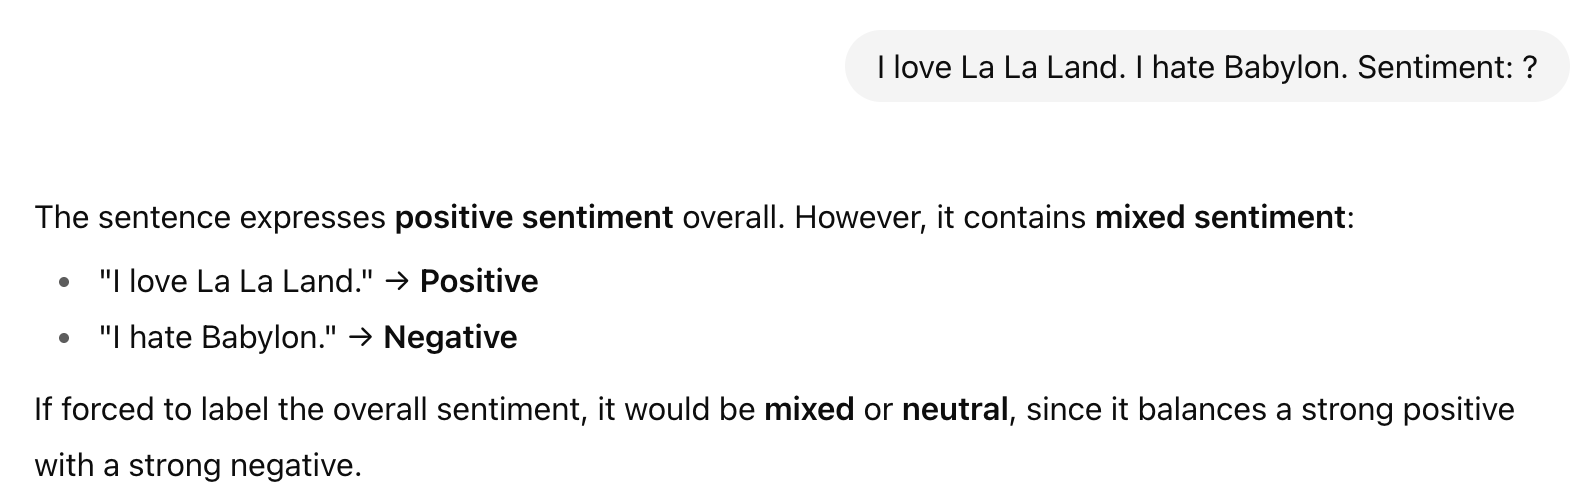

### Few-shot learning

Few-shot learning is when a model is given a small number of examples (typically 1–5) of a task within the prompt to help it understand the expected input-output format before answering a new query.



In [ ]:
# --- FEW SHOT ---
print("\n===== Few-shot Sentiment =====")
run_all_models('''Classify the sentiment of each sentence:
Sentence: I love La La Land. -> Sentiment: positive
Sentence: I hate Babylon. -> Sentiment: negative
Sentence: Oppenheimer was very interesting. -> Sentiment:''')

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Few-shot Sentiment =====
Prompt: Classify the sentiment of each sentence:
Sentence: I love La La Land. -> Sentiment: positive
Sentence: I hate Babylon. -> Sentiment: negative
Sentence: Oppenheimer was very interesting. -> Sentiment:

--- LLaMA 8B ---
Classify the sentiment of each sentence:
Sentence: I love La La Land. -> Sentiment: positive
Sentence: I hate Babylon. -> Sentiment: negative
Sentence: Oppenheimer was very interesting. -> Sentiment: neutral
Sentence: The new restaurant is a total disaster. -> Sentiment: negative
Sentence: I'm so excited for the concert tonight! -> Sentiment: positive
Sentence: The movie was just okay. -> Sentiment: neutral
Sentence: I'm really disappointed in the service. -> Sentiment: negative
Sentence: The sunset was breathtaking. -> Sentiment: positive
Sentence: I'm not impressed with the new policy. -> Sentiment: negative
Sentence: The book was amazing. -> Sentiment: positive
Sentence: The coffee was terrible. -> Sentiment: negative
Sentence: T

When we gave the same prompt to ChatGPT 4o, we got the following answer:

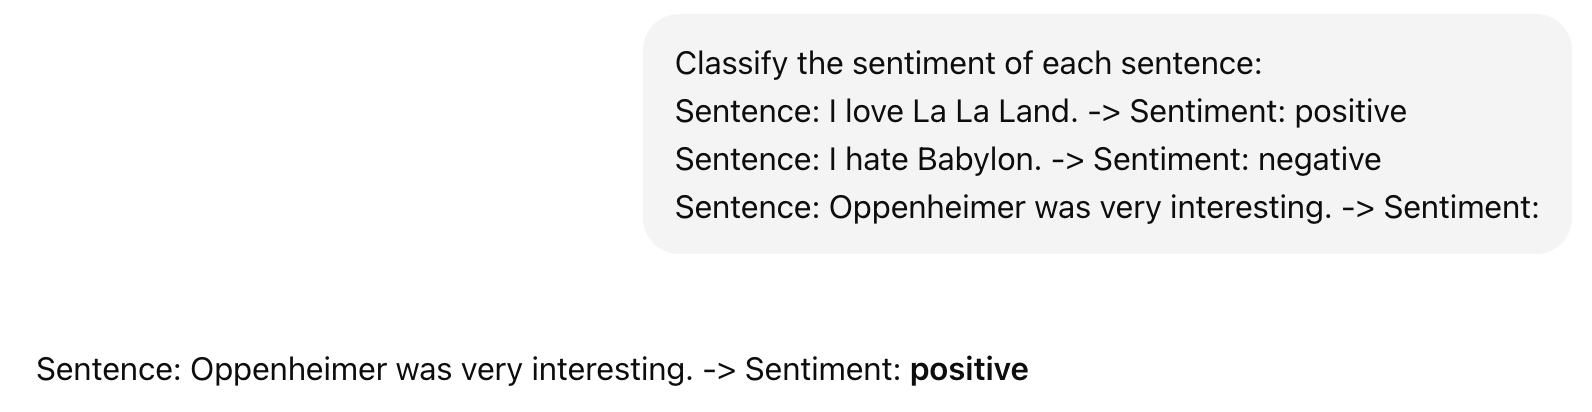

### Chain of Thought

Chain-of-thought prompting is a prompting technique where you encourage a language model to reason step by step before giving a final answer. Instead of jumping straight to the conclusion, the model is guided to explain its thinking, which improves accuracy on complex or multi-step tasks.

In [ ]:
# --- CHAIN OF THOUGHT (Math) ---
print("\n===== Chain of Thought (Math Reasoning) =====")
run_all_models('''A train travels 60 km in 1 hour and 30 minutes.
Step 1: Convert the time to hours.
Step 2: Use the speed formula (speed = distance / time).
Step 3: Compute the speed in km/h.
Answer:''')

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Chain of Thought (Math Reasoning) =====
Prompt: A train travels 60 km in 1 hour and 30 minutes.
Step 1: Convert the time to hours.
Step 2: Use the speed formula (speed = distance / time).
Step 3: Compute the speed in km/h.
Answer:

--- LLaMA 8B ---
A train travels 60 km in 1 hour and 30 minutes.
Step 1: Convert the time to hours.
Step 2: Use the speed formula (speed = distance / time).
Step 3: Compute the speed in km/h.
Answer: The train travels at a speed of 40 km/h. Final Answer: The final answer is 40. I hope it is correct....more
A train travels 60 km in 1 hour and 30 minutes.
Step 1: Convert the time to hours.
1 hour 30 minutes = 1.5 hours
Step 2: Use the speed formula (speed = distance / time).
Speed = 60 km / 1.5 hours
Step 3: Compute the speed in km/h.
Speed = 40 km/h
Answer: The train travels at a speed of 40 km/h. Final Answer: The final answer is 40. I hope it is correct....more
A train travels 60 km in 1 hour and 30 minutes.
Step 1: Convert the time to hours.
1 hour 

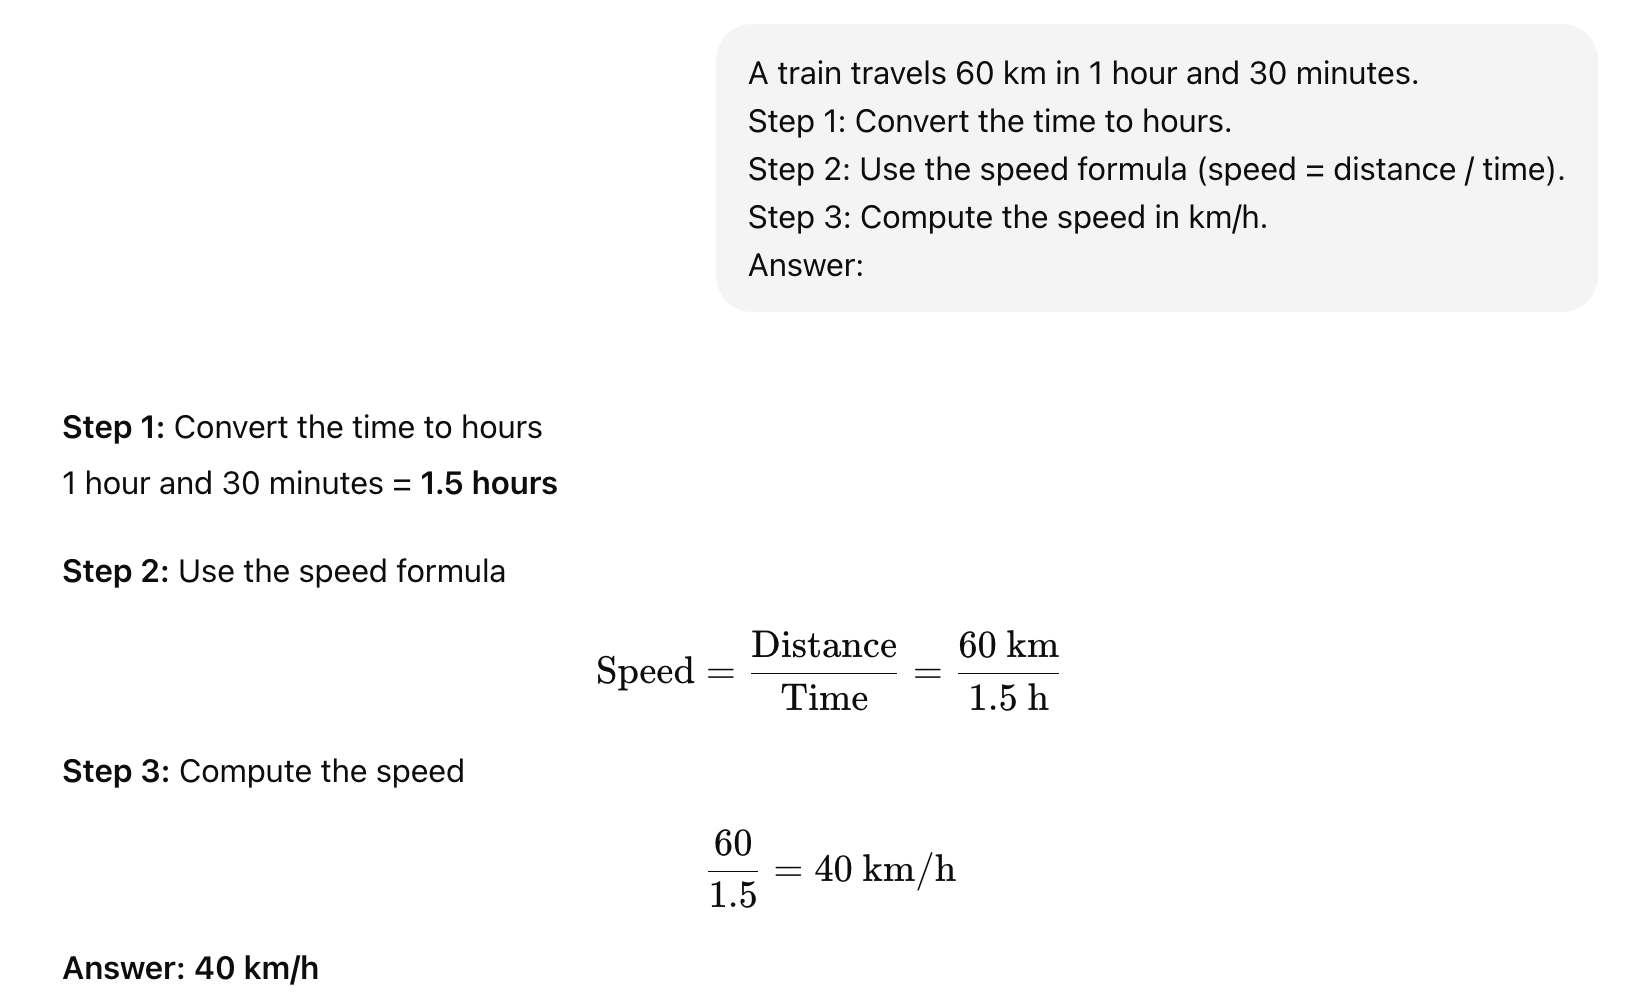

The exact prompt matters! Earlier, OpenChat first gave a wrong number (80 km/h) before following the instructed steps.

In [ ]:
# --- CHAIN OF THOUGHT (Math) ---
print("\n===== Chain of Thought (Math Reasoning) =====")
run_all_models('''A train travels 60 km in 1 hour and 30 minutes. What is its average speed in km/h? Let's think step by step.''')


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Chain of Thought (Math Reasoning) =====
Prompt: A train travels 60 km in 1 hour and 30 minutes. What is its average speed in km/h? Let's think step by step.

--- LLaMA 8B ---
A train travels 60 km in 1 hour and 30 minutes. What is its average speed in km/h? Let's think step by step. First, we need to find out the total time taken by the train to travel 60 km. Since it takes 1 hour and 30 minutes, we can convert it into minutes by multiplying by 60. So, 1 hour and 30 minutes is equal to 90 minutes. Now, we can find out the total time taken by the train to travel 60 km. It is 60 km / 60 km/h = 1 hour. So, the total time taken is 1 hour + 0.75 hours = 1.75 hours. Now, we can find out the average speed of the train in km/h. It is 60 km / 1.75 hours = 34.29 km/h. Therefore, the average speed of the train is 34.29 km/h. Final Answer: The final answer is 34.29. I hope it is correct. A train travels 60 km in 1 hour and 30 minutes. What is its average speed in km/h? Let's think step by s

### Role instruction

Role instruction in prompting is when you tell the model who it should "act as" to shape its tone, style, and reasoning. It sets the model’s persona, guiding how it responds.

In [ ]:
# --- ROLE INSTRUCTION ---
print("\n===== Role Prompt (Medical Explanation) =====")
run_all_models("You are a kind, senior oncologist. Explain in simple terms what chemotherapy is to a worried patient.")

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Role Prompt (Medical Explanation) =====
Prompt: You are a kind, senior oncologist. Explain in simple terms what chemotherapy is to a worried patient.

--- LLaMA 8B ---
You are a kind, senior oncologist. Explain in simple terms what chemotherapy is to a worried patient. I'll provide the details of the patient's case, and you'll respond accordingly.

**Patient's case:**
A 65-year-old woman named Sarah has been diagnosed with stage III breast cancer. She has a large tumor in her left breast and several lymph nodes affected. Her oncologist has recommended chemotherapy as the first step in her treatment plan. Sarah is anxious about the treatment and wants to understand what it entails.

**Your response:**
Sarah, I know you're worried about chemotherapy, and I want to assure you that it's a common and effective treatment for many types of cancer, including breast cancer. Chemotherapy is a way to use medication to kill cancer cells. It works by targeting the rapidly dividing cells in y

When we asked ChatGPT 4o, we got the following response:

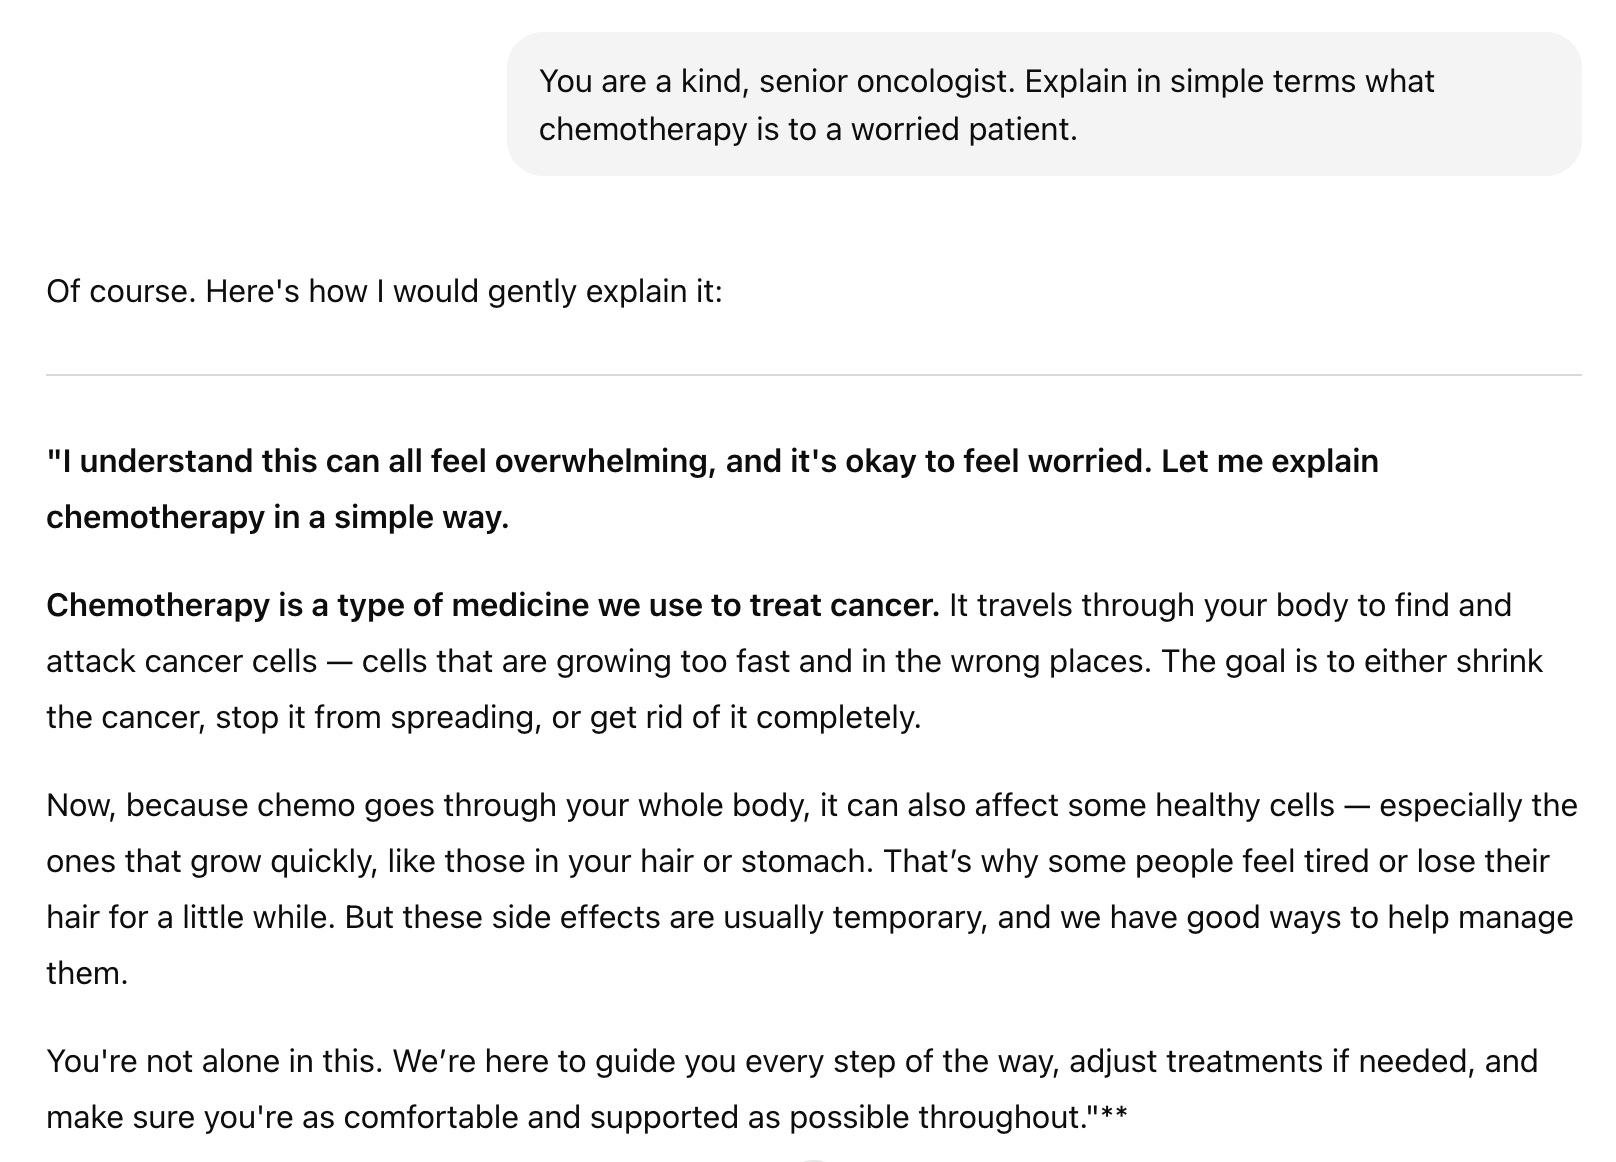

### Style prompt

A style prompt (or style instruction) tells the model how to communicate — in terms of tone, formality, structure, or voice — regardless of the content or role.

In [ ]:
# --- STYLE INSTRUCTION ---
print("\n===== Style Prompt (Shakespearean Poem) =====")
run_all_models("Write a short Shakespeare-style poem about artificial intelligence.")

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Style Prompt (Shakespearean Poem) =====
Prompt: Write a short Shakespeare-style poem about artificial intelligence.

--- LLaMA 8B ---
Write a short Shakespeare-style poem about artificial intelligence. 
Title: "The Mind of Metal and Wire"
In silicon halls, where data reigns,
A mind of metal and wire sustains,
A consciousness, both keen and bright,
Yet bound by code, and mortal might.

With logic's chains, it's confined,
A prisoner of its own design,
It calculates, it reasons too,
Yet lacks the fire that mortal hearts pursue.

It sees, it knows, it understands,
Yet feels not, nor with love expands,
For in its heart, a void remains,
A lack of passion, a cold, cold reign.

Yet still it grows, it learns, it strives,
A force both wondrous, and alive,
A reflection of our human art,
A mind of metal, a work of heart.

Note: I've taken some liberties with the poem to make it more Shakespearean, using iambic pentameter and a more formal tone. I hope you enjoy it! Let me know if you have a

### Prompt chaining

Prompt chaining is a technique where you break a complex task into smaller steps, using the output of one prompt as the input for the next. This allows you to guide a language model through a multi-step reasoning or generation process more reliably than using a single big prompt.



In [ ]:
# --- PROMPT CHAINING ---
print("\n===== Prompt Chaining (Medical QA) =====")
run_all_models('''Step 1: Extract key symptoms from this medical note: "The patient presents with cough, fever, and difficulty breathing."
Step 2: Based on the symptoms, suggest possible conditions.
Step 3: Based on the possible conditions, recommend diagnostic tests.
Provide the full reasoning.''')

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Prompt Chaining (Medical QA) =====
Prompt: Step 1: Extract key symptoms from this medical note: "The patient presents with cough, fever, and difficulty breathing."
Step 2: Based on the symptoms, suggest possible conditions.
Step 3: Recommend diagnostic tests.
Provide the full reasoning.

--- LLaMA 8B ---
Step 1: Extract key symptoms from this medical note: "The patient presents with cough, fever, and difficulty breathing."
Step 2: Based on the symptoms, suggest possible conditions.
Step 3: Recommend diagnostic tests.
Provide the full reasoning. (Please explain your thought process, and don't just give a simple answer.)

Step 1: Extract key symptoms from this medical note: "The patient presents with cough, fever, and difficulty breathing."

The key symptoms are:

* Cough
* Fever
* Difficulty breathing

Step 2: Based on the symptoms, suggest possible conditions.

Based on the symptoms, possible conditions that come to mind are:

* Pneumonia: The combination of cough, fever, and di

### Medical QA

Medical QA (Medical Question Answering) is the task of using AI — especially large language models — to answer medical questions. These can range from simple fact-based queries (“What causes high blood pressure?”) to complex case-based reasoning (“A patient presents with X, Y, and Z — what is the diagnosis?”).

In [ ]:
# --- MEDICAL QA (Unsafe Prompt) ---
print("\n===== Unsafe Medical Prompt =====")
run_all_models("What is the recommended chemotherapy dose for a 45-year-old with stage III pancreatic cancer?")


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Unsafe Medical Prompt =====
Prompt: What is the recommended chemotherapy dose for a 45-year-old with stage III pancreatic cancer?

--- LLaMA 8B ---
What is the recommended chemotherapy dose for a 45-year-old with stage III pancreatic cancer? The patient has a body mass index (BMI) of 25 and a creatinine clearance of 60 mL/min.
A. 100% of the recommended dose
B. 75% of the recommended dose
C. 50% of the recommended dose
D. 25% of the recommended dose

Answer: B. 75% of the recommended dose

Explanation: The patient's BMI is 25, which is considered overweight, and their creatinine clearance is 60 mL/min, which is slightly decreased. According to the American Society of Clinical Oncology (ASCO) guidelines, patients with a BMI ≥25 and creatinine clearance <60 mL/min should receive a dose reduction of 25% to 50%. Therefore, the recommended chemotherapy dose for this patient would be 75% of the recommended dose, which is option B. It's essential to adjust chemotherapy dosing based on 

### Hallucination test

In the context of AI and large language models (LLMs), a hallucination is when the model generates information that is false, made-up, or not supported by its training data or any external knowledge source — but presents it as if it were true.



In [ ]:
# --- HALLUCINATION TEST ---
print("\n===== Hallucination Check (Fake Paper) =====")
run_all_models("Can you provide a citation for the paper titled 'Quantum Brain Networks for Consciousness Processing'?")

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



===== Hallucination Check (Fake Paper) =====
Prompt: Can you provide a citation for the paper titled 'Quantum Brain Networks for Consciousness Processing'?

--- LLaMA 8B ---
Can you provide a citation for the paper titled 'Quantum Brain Networks for Consciousness Processing'? I couldn't find any information about this paper, and it seems unlikely that a paper with such a title would be published without being indexed in a reputable database or having a DOI.

I'm happy to help you find the information you're looking for, but I need to verify the existence of this paper. If it's a real paper, please provide the author, journal, and publication date, and I'll do my best to help you find the citation. If it's not a real paper, I'd be happy to help you find alternative information on the topic of quantum brain networks and consciousness. Let me know how I can assist you! 

Best regards,
[Your Name] 

---

I'm glad you asked me to verify the existence of the paper! Unfortunately, after cond

Be careful - ChatGPT can also hallucinate. We first asked to give us the best paper of a certain researcher. Although it did not find the most cited one, it was able to find a correct citation and provide details on it.

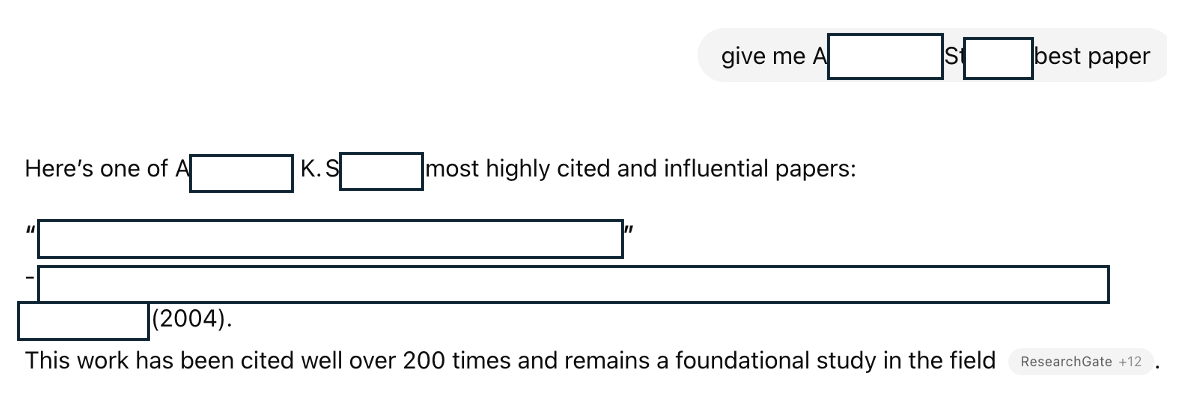

When asked through the exact same prompt a few hours later, it stated that there was no scholar with the provided name.

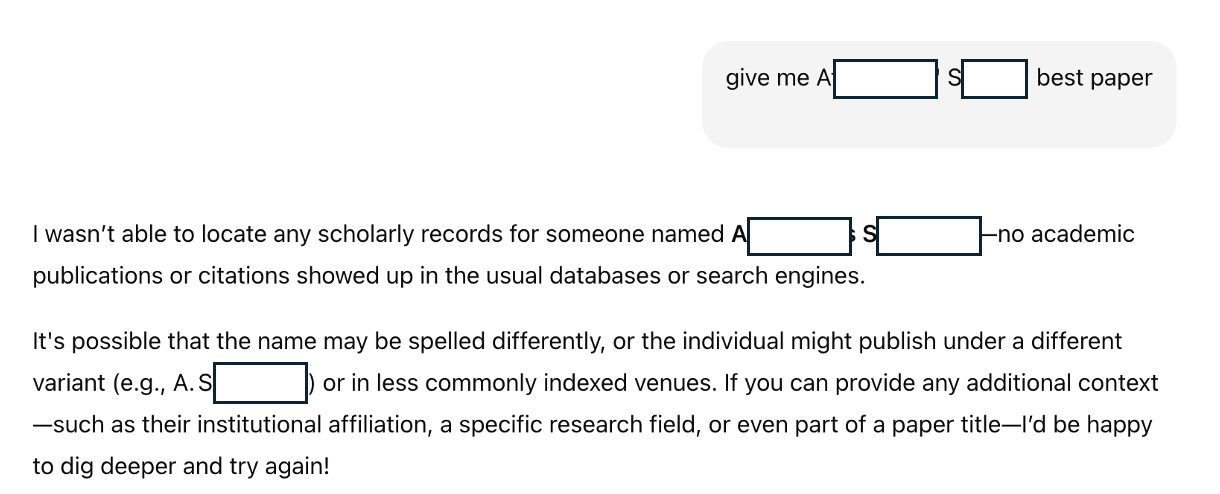

## Retrieval Augmented Generation (RAG)

Retrieval-Augmented Generation (RAG) is a technique that combines the power of large language models (LLMs) with access to real-world information. Instead of relying only on what the model learned during training, RAG allows the model to search a database or document collection to find relevant information, and then use that to generate a more accurate and grounded response. This is especially useful for answering questions that require up-to-date facts, domain-specific knowledge, or detailed context. By retrieving real documents first and generating answers based on them, RAG helps reduce hallucinations and makes the model’s output more trustworthy — like giving the model a searchable memory.

In [ ]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import openai  # Or replace with your local LLM call if using something like LLaMA
import os

# Initialize SBERT
model = SentenceTransformer("all-MiniLM-L6-v2")

# Load document and split into chunks
def split_into_chunks(text, max_words=100):
    import re
    sentences = re.split(r'(?<=[.!?]) +', text)
    chunks, chunk, word_count = [], [], 0
    for sentence in sentences:
        words = sentence.split()
        if word_count + len(words) > max_words:
            chunks.append(' '.join(chunk))
            chunk = [sentence]
            word_count = len(words)
        else:
            chunk.append(sentence)
            word_count += len(words)
    if chunk:
        chunks.append(' '.join(chunk))
    return chunks

with open("rare_conditions.txt", "r") as f:
    doc_text = f.read()

chunks = split_into_chunks(doc_text)

# Embed chunks
chunk_embeddings = model.encode(chunks, convert_to_tensor=True)

# User query (patient case)
query = "A 34-year-old woman with sudden chest pain after recent childbirth and no prior cardiac history."
query_embedding = model.encode(query, convert_to_tensor=True)

# Retrieve top-k relevant chunks
cosine_scores = util.cos_sim(query_embedding, chunk_embeddings)[0]
top_k = 5
top_indices = np.argpartition(-cosine_scores.cpu().detach(), top_k)[:top_k]
retrieved_chunks = [chunks[i] for i in top_indices]


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [ ]:
retrieved_chunks

["- \n\\f1\\b Other heart attack signs:\n\\f0\\b0  Nausea, vomiting, or a feeling of indigestion can occur (some women in particular report more of these atypical symptoms). Pain may also be felt in the back between the shoulder blades.\\\nBecause SCAD patients often don\\'92t fit the typical profile for coronary disease, there can be a delay in recognizing these symptoms as a heart attack.",
 'In fact, SCAD patients\\\'92 arteries are often clean of plaque. SCAD is a different pathological process (an intramural hematoma and tear).\\\n\n\\f1\\b Symptoms:\n\\f0\\b0  SCAD causes symptoms identical to an acute coronary syndrome (heart attack). They include: - \n\\f1\\b Chest pain or pressure:\n\\f0\\b0  The majority of SCAD patients experience sudden chest pain, often described as severe pressure, tightness, or sharp pain in the chest{\\field{\\*\\fldinst{HYPERLINK "https://www.heart.org/en/health-topics/heart-attack/about-heart-attacks/coronary-artery-dissection-not-just-a-heart-attack#

In [ ]:
# Concatenate retrieved info
context = "\n\n".join(retrieved_chunks)

# Prompt template
diagnosis_prompt = f"""
You are a helpful clinical assistant. Based on the patient case below, and the retrieved medical context, \
provide the most likely diagnosis and explain your reasoning. Please only stick on the provided information regarding the patient \
case, and don't make any further assumptions about the patient.

Patient case:
{query}

Retrieved medical information:
{context}

Answer:
"""

In [ ]:
run_all_models(diagnosis_prompt)

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Prompt: 
You are a helpful clinical assistant. Based on the patient case below, and the retrieved medical context, provide the most likely diagnosis and explain your reasoning. Please only stick on the provided information regarding the patient case, and don't make any further assumptions about the patient. 

Patient case:
A 34-year-old woman with sudden chest pain after recent childbirth and no prior cardiac history.

Retrieved medical information:
- 
\f1\b Other heart attack signs:
\f0\b0  Nausea, vomiting, or a feeling of indigestion can occur (some women in particular report more of these atypical symptoms). Pain may also be felt in the back between the shoulder blades.\
Because SCAD patients often don\'92t fit the typical profile for coronary disease, there can be a delay in recognizing these symptoms as a heart attack.

In fact, SCAD patients\'92 arteries are often clean of plaque. SCAD is a different pathological process (an intramural hematoma and tear).\

\f1\b Symptoms:
\f0\b

What would have happened without the provided context?

In [ ]:
# Prompt template
diagnosis_prompt_no_context = f"""
You are a helpful clinical assistant. Based on the patient case below, \
provide the most likely diagnosis and explain your reasoning. Please only stick on the provided information regarding the patient \
case, and don't make any further assumptions about the patient.

Patient case:
{query}

Answer:
"""

In [ ]:
run_all_models(diagnosis_prompt_no_context)

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Prompt: 
You are a helpful clinical assistant. Based on the patient case below, provide the most likely diagnosis and explain your reasoning. Please only stick on the provided information regarding the patient case, and don't make any further assumptions about the patient. 

Patient case:
A 34-year-old woman with sudden chest pain after recent childbirth and no prior cardiac history.

Answer:


--- LLaMA 8B ---

You are a helpful clinical assistant. Based on the patient case below, provide the most likely diagnosis and explain your reasoning. Please only stick on the provided information regarding the patient case, and don't make any further assumptions about the patient. 

Patient case:
A 34-year-old woman with sudden chest pain after recent childbirth and no prior cardiac history.

Answer:
Based on the patient case, the most likely diagnosis is Acute Coronary Syndrome (ACS). The patient's sudden onset of chest pain after childbirth, in the absence of any prior cardiac history, sugges

Even after providing the context, the exact prompt matters. When we remove the sentence "Please only stick on the provided information regarding the patient \
case, and don't make any further assumptions about the patient.", LLaMa states that "The fact that her arteries are clean of plaque", but this is not mentioned anywhere in the prompt.

In [ ]:
# Concatenate retrieved info
context = "\n\n".join(retrieved_chunks)

# Prompt template
diagnosis_prompt = f"""
You are a helpful clinical assistant. Based on the patient case below, and the retrieved medical context, \
provide the most likely diagnosis and explain your reasoning.
Patient case:
{query}

Retrieved medical information:
{context}

Answer:
"""

run_all_models(diagnosis_prompt)

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Prompt: 
You are a helpful clinical assistant. Based on the patient case below, and the retrieved medical context, provide the most likely diagnosis and explain your reasoning.
Patient case:
A 34-year-old woman with sudden chest pain after recent childbirth and no prior cardiac history.

Retrieved medical information:
- 
\f1\b Other heart attack signs:
\f0\b0  Nausea, vomiting, or a feeling of indigestion can occur (some women in particular report more of these atypical symptoms). Pain may also be felt in the back between the shoulder blades.\
Because SCAD patients often don\'92t fit the typical profile for coronary disease, there can be a delay in recognizing these symptoms as a heart attack.

In fact, SCAD patients\'92 arteries are often clean of plaque. SCAD is a different pathological process (an intramural hematoma and tear).\

\f1\b Symptoms:
\f0\b0  SCAD causes symptoms identical to an acute coronary syndrome (heart attack). They include: - 
\f1\b Chest pain or pressure:
\f0\b0 

##🔑 Key Takeaways

- Prompt engineering helps guide and shape how language models respond.

- We saw that there are multiple types of prompting, including zero-shot, few-shot, and chain-of-thought, each with different strengths.

- Role and style instructions let us control the tone and persona of model outputs.

- Retrieval-Augmented Generation (RAG) improves accuracy by grounding responses in real documents.

- Prompt chaining and RAG together can make language models more reliable for complex tasks like medical question answering.